# Système intelligent de surveillance de la dracunculose animale au Tchad

## Analyse exploratoire et préparation des données

### Objectif

Ce notebook constitue la première étape du projet de Machine Learning.

L'objectif général est de développer un modèle capable de prédire
le nombre d'infections animales par province pour l'année 2026.

Les données historiques disponibles couvrent la période 2022-2025.

Les principaux facteurs de risque étudiés sont :

- le nombre d'infections animales ;
- le nombre d'infections non isolées ;
- le nombre de sources d'eau contaminées ;
- le nombre d'animaux non attachés.

Cette première partie est consacrée à l'analyse exploratoire,
au contrôle de la qualité des données et à la préparation des
variables nécessaires à la modélisation.

1- Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


2- Chargement des données

In [2]:
df = pd.read_csv("Infections_Animales.csv", sep=";")
df.head()

,Année,Mois,Date d'emergence,No Serie Infection,Type d'animal,Province,District,Zone,Village,Quartier,...,Sexe de l'age,Nom de l'animal,Type d'attachement,Animal Attache,Contamination des Sources d'eau,Date de detection,Date d'Investigation,Infection Isolee?,Latitude,Longitude
0,2025,Janvier,01/01/2025,1,Chien Domestique,Tandjile,Lai,Gabri-ngolo,Hamakara,Pas de Quartier,...,M,Servi,Non-_Lanimal_nest_pas_attache,Non,Non,01/01/2025,01/01/2025,Oui,9.294136,16.352733
1,2025,Janvier,03/01/2025,2,Chien Domestique,MC,Sarh,Maibo,Kotbiri,Pas de Quartier,...,M,Patience,Oui- Attaché avec une chaîne et deux cadenas,Oui,Oui,01/01/2025,03/01/2025,Non,8.991139,18.505587
2,2025,Janvier,07/01/2025,3,Chien Domestique,MKE,Guelendeng,Mitau,Goussou,Pas de Quartier,...,M,Marba,Oui- Attaché avec une chaîne et deux cadenas,Oui,Oui,03/01/2025,03/01/2025,Non,10.84542,15.697289
3,2025,Janvier,16/01/2025,4,Chien Domestique,SLM,Haraze,Daha,Miabesse,Pas de Quartier,...,F,Khachoumnass,Oui-_Attache_avec_une_chaine_et_deux_cadenas,Oui,Non,13/01/2025,14/01/2025,Non,9.337588,20.535028
4,2025,Janvier,19/01/2025,5,Chien Domestique,SLM,Haraze,Daha,Ndobe,Pas de Quartier,...,M,Machato,Non-_Lanimal_nest_pas_attache,Non,Oui,18/01/2025,20/01/2025,Non,9.29918,20.487122


In [3]:
df.shape

(1521, 23)

In [4]:
df.columns

Index(['Année', 'Mois', 'Date d'emergence', 'No Serie Infection',
       'Type d'animal', 'Province', 'District', 'Zone', 'Village', 'Quartier',
       'Code QR Animale', 'Animal Sous APCC', 'Age de l'Animal',
       'Sexe de l'age', 'Nom de l'animal', 'Type d'attachement',
       'Animal Attache', 'Contamination des Sources d'eau',
       'Date de detection', 'Date d'Investigation', 'Infection Isolee?',
       'Latitude', 'Longitude'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1521 entries, 0 to 1520
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Année                            1521 non-null   int64
 1   Mois                             1521 non-null   str  
 2   Date d'emergence                 1521 non-null   str  
 3   No Serie Infection               1521 non-null   int64
 4   Type d'animal                    1521 non-null   str  
 5   Province                         1521 non-null   str  
 6   District                         1521 non-null   str  
 7   Zone                             1521 non-null   str  
 8   Village                          1521 non-null   str  
 9   Quartier                         1521 non-null   str  
 10  Code QR Animale                  1521 non-null   str  
 11  Animal Sous APCC                 1521 non-null   str  
 12  Age de l'Animal                  1521 non-null   str  
 13 

3- Valeurs manquantes

In [6]:
missing = df.isnull().sum()/len(df) * 100
print("Nombre de valeurs manquantes par colonne :")
print(missing)

Nombre de valeurs manquantes par colonne :
Année                              0.000000
Mois                               0.000000
Date d'emergence                   0.000000
No Serie Infection                 0.000000
Type d'animal                      0.000000
Province                           0.000000
District                           0.000000
Zone                               0.000000
Village                            0.000000
Quartier                           0.000000
Code QR Animale                    0.000000
Animal Sous APCC                   0.000000
Age de l'Animal                    0.000000
Sexe de l'age                      0.000000
Nom de l'animal                    0.000000
Type d'attachement                 0.000000
Animal Attache                     0.000000
Contamination des Sources d'eau    0.000000
Date de detection                  0.000000
Date d'Investigation               0.000000
Infection Isolee?                  0.000000
Latitude                         

In [8]:
df.describe()

,Année,No Serie Infection
count,1521.000000,1521.000000
mean,2022.983563,232.561473
std,0.980933,160.385130
min,2022.000000,1.000000
25%,2022.000000,96.000000
50%,2023.000000,206.000000
75%,2024.000000,358.000000
max,2025.000000,599.000000


4- Doublons

In [9]:
nombre_doublons = df.duplicated().sum()
print(f"Nombre de doublons : {nombre_doublons}")

Nombre de doublons : 0


5- Identification de l'année

In [10]:
def trouver_colonne(df, candidats):
    """
    Recherche une colonne parmi plusieurs noms possibles.
    """
    colonnes_normalisees = {
        str(col).strip().lower(): col
        for col in df.columns
    }
    for candidat in candidats:
        candidat_normalise = (
            candidat.strip().lower()
        )
        if candidat_normalise in colonnes_normalisees:
            return colonnes_normalisees[
                candidat_normalise
            ]
    return None

In [11]:
COL_ANNEE = trouver_colonne(
    df,
    [
        "Année",
        "Annee",
        "année",
        "annee",
        "Year"
    ]
)
COL_PROVINCE = trouver_colonne(
    df,
    [
        "Province",
        "province"
    ]
)
print("Colonne année :", COL_ANNEE)
print("Colonne province :", COL_PROVINCE)

Colonne année : Année
Colonne province : Province


In [12]:
if COL_ANNEE is None:
    raise ValueError(
        "Impossible de trouver la colonne Année."
    )
if COL_PROVINCE is None:
    raise ValueError(
        "Impossible de trouver la colonne Province."
    )

6- Nettoyage de l'année

In [13]:
df[COL_ANNEE] = pd.to_numeric(
    df[COL_ANNEE],
    errors="coerce"
)
df = df.dropna(
    subset=[COL_ANNEE, COL_PROVINCE]
)
df[COL_ANNEE] = (
    df[COL_ANNEE]
    .astype(int)
)
print(
    "Années disponibles :",
    sorted(df[COL_ANNEE].unique())
)

Années disponibles : [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


7- Distribution des infections par année

In [14]:

# Nombre d'observations par année


infections_annee = (
    df.groupby(COL_ANNEE)
      .size()
      .reset_index(name="Nombre_infections")
)

display(infections_annee)

,Année,Nombre_infections
0,2022,598
1,2023,496
2,2024,281
3,2025,146


Graphique d'évolution

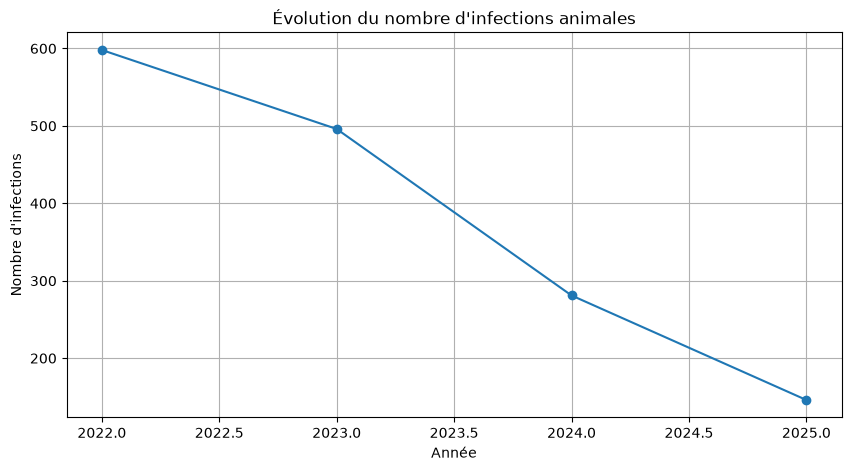

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(
    infections_annee[COL_ANNEE],
    infections_annee["Nombre_infections"],
    marker="o"
)
plt.title(
    "Évolution du nombre d'infections animales"
)
plt.xlabel("Année")
plt.ylabel("Nombre d'infections")
plt.grid(True)
plt.show()

8- Nombre d'infections par province

In [16]:
infections_province = (
    df.groupby(COL_PROVINCE)
      .size()
      .sort_values(ascending=False)
)
display(
    infections_province.to_frame(
        "Nombre_infections"
    )
)

,Nombre_infections
Province,
MC,482
MKE,431
CB,263
Tandjile,214
LOC,51
SLM,41
NDJ,21
MDL,10
Guera,4


Graphique des provinces

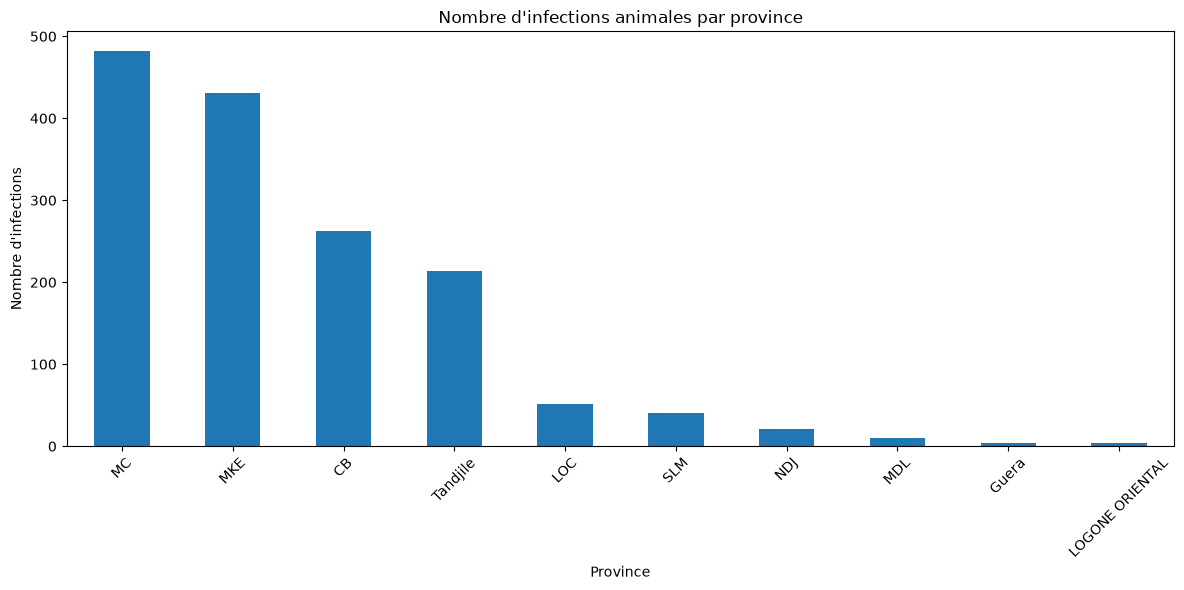

In [17]:
plt.figure(figsize=(12, 6))
infections_province.plot(
    kind="bar"
)
plt.title(
    "Nombre d'infections animales par province"
)
plt.xlabel("Province")
plt.ylabel("Nombre d'infections")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

9- Analyse des facteurs de risque

In [18]:
COL_ATTACHE = trouver_colonne(
    df,
    [
        "Animal Attache",
        "Animal Attaché",
        "Animal Attache?",
        "Animal Attaché?"
    ]
)

COL_ISOLE = trouver_colonne(
    df,
    [
        "Infection Isolee?",
        "Infection Isolée?",
        "Infection Isolee",
        "Infection Isolée"
    ]
)

COL_EAU = trouver_colonne(
    df,
    [
        "Contamination des Sources d'eau",
        "Contamination des Sources d’eau",
        "Source d'eau contaminée"
    ]
)

print("Animal attaché :", COL_ATTACHE)
print("Infection isolée :", COL_ISOLE)
print("Contamination eau :", COL_EAU)

Animal attaché : Animal Attache
Infection isolée : Infection Isolee?
Contamination eau : Contamination des Sources d'eau


10- Vérification des valeurs

In [19]:
for colonne in [
    COL_ATTACHE,
    COL_ISOLE,
    COL_EAU
]:
    if colonne is not None:
        print("\n==============================")
        print(colonne)
        print("==============================")

        print(
            df[colonne]
            .value_counts(dropna=False)
        )


Animal Attache
Animal Attache
Non    807
Oui    714
Name: count, dtype: int64

Infection Isolee?
Infection Isolee?
Oui    1078
Non     443
Name: count, dtype: int64

Contamination des Sources d'eau
Contamination des Sources d'eau
Non    1226
Oui     295
Name: count, dtype: int64


11- Création des indicateurs

In [20]:
# ============================================================
# Fonction permettant de reconnaître Oui / Non
# ============================================================
def est_non(valeur):
    return str(valeur).strip().lower() in [
        "non",
        "no",
        "0"
    ]
def est_oui(valeur):
    return str(valeur).strip().lower() in [
        "oui",
        "yes",
        "1"
    ]

In [21]:
# ============================================================
# Création des indicateurs
# ============================================================
df["animal_non_attache"] = 0
df["infection_non_isolee"] = 0
df["source_eau_contaminee"] = 0
if COL_ATTACHE is not None:
    df["animal_non_attache"] = (
        df[COL_ATTACHE]
        .apply(est_non)
        .astype(int)
    )
if COL_ISOLE is not None:
    df["infection_non_isolee"] = (
        df[COL_ISOLE]
        .apply(est_non)
        .astype(int)
    )
if COL_EAU is not None:
    df["source_eau_contaminee"] = (
        df[COL_EAU]
        .apply(est_oui)
        .astype(int)
    )

12- Résumé des facteurs de risque

In [22]:
facteurs = [
    "animal_non_attache",
    "infection_non_isolee",
    "source_eau_contaminee"
]
resume_facteurs = df[facteurs].sum()
display(
    resume_facteurs.to_frame(
        "Nombre_de_cas"
    )
)

,Nombre_de_cas
animal_non_attache,807
infection_non_isolee,443
source_eau_contaminee,295


13- Analyse temporelle des facteurs

In [23]:
facteurs_annee = (
    df.groupby(COL_ANNEE)[facteurs]
      .sum()
)
display(facteurs_annee)

,animal_non_attache,infection_non_isolee,source_eau_contaminee
Année,,,
2022,14,174,97
2023,455,120,85
2024,229,93,71
2025,109,56,42


Graphique des facteurs

<Figure size 1200x600 with 0 Axes>

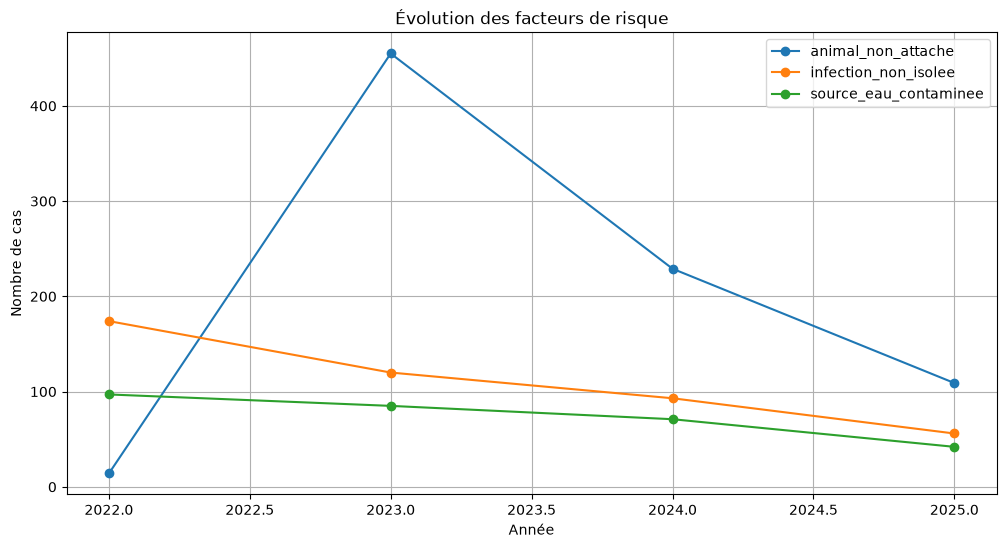

In [24]:
plt.figure(figsize=(12, 6))
facteurs_annee.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)
plt.title(
    "Évolution des facteurs de risque"
)
plt.xlabel("Année")
plt.ylabel("Nombre de cas")
plt.grid(True)
plt.show()

14- Construction du dataset de modélisation

In [26]:
# Agrégation par année et province
data_model = (
    df.groupby(
        [COL_ANNEE, COL_PROVINCE]
    )
    .agg(
        infections=(
            COL_PROVINCE,
            "size"
        ),
        non_attaches=(
            "animal_non_attache",
            "sum"
        ),
        non_isolees=(
            "infection_non_isolee",
            "sum"
        ),
        eau_contaminee=(
            "source_eau_contaminee",
            "sum"
        )
    )
    .reset_index()
)

display(data_model.head())

,Année,Province,infections,non_attaches,non_isolees,eau_contaminee
0,2022,CB,102,0,27,14
1,2022,LOC,13,0,8,6
2,2022,LOGONE ORIENTAL,1,0,1,0
3,2022,MC,216,6,58,38
4,2022,MDL,2,0,0,0


15- Variables retardées

In [27]:
# Variables de l'année précédente


data_model = data_model.sort_values(
    [COL_PROVINCE, COL_ANNEE]
)

data_model["infections_precedentes"] = (
    data_model
    .groupby(COL_PROVINCE)["infections"]
    .shift(1)
)

data_model["non_attaches_precedents"] = (
    data_model
    .groupby(COL_PROVINCE)["non_attaches"]
    .shift(1)
)

data_model["non_isolees_precedentes"] = (
    data_model
    .groupby(COL_PROVINCE)["non_isolees"]
    .shift(1)
)

data_model["eau_contaminee_precedente"] = (
    data_model
    .groupby(COL_PROVINCE)["eau_contaminee"]
    .shift(1)
)

display(data_model.head(20))

,Année,Province,infections,non_attaches,non_isolees,eau_contaminee,infections_precedentes,non_attaches_precedents,non_isolees_precedentes,eau_contaminee_precedente
0,2022,CB,102,0,27,14,NaN,NaN,NaN,NaN
9,2023,CB,99,88,27,19,102.0,0.0,27.0,14.0
18,2024,CB,56,43,14,9,99.0,88.0,27.0,19.0
28,2025,CB,6,5,3,3,56.0,43.0,14.0,9.0
10,2023,Guera,1,1,0,0,NaN,NaN,NaN,NaN
19,2024,Guera,3,2,0,0,1.0,1.0,0.0,0.0
1,2022,LOC,13,0,8,6,NaN,NaN,NaN,NaN
11,2023,LOC,21,21,3,2,13.0,0.0,8.0,6.0
20,2024,LOC,16,15,1,1,21.0,21.0,3.0,2.0
29,2025,LOC,1,1,1,0,16.0,15.0,1.0,1.0


16- Dataset final

In [28]:
data_ml = data_model.dropna().copy()
print(
    "Nombre d'observations utilisables :",
    len(data_ml)
)
display(data_ml)

Nombre d'observations utilisables : 26


,Année,Province,infections,non_attaches,non_isolees,eau_contaminee,infections_precedentes,non_attaches_precedents,non_isolees_precedentes,eau_contaminee_precedente
9,2023,CB,99,88,27,19,102.0,0.0,27.0,14.0
18,2024,CB,56,43,14,9,99.0,88.0,27.0,19.0
28,2025,CB,6,5,3,3,56.0,43.0,14.0,9.0
19,2024,Guera,3,2,0,0,1.0,1.0,0.0,0.0
11,2023,LOC,21,21,3,2,13.0,0.0,8.0,6.0
20,2024,LOC,16,15,1,1,21.0,21.0,3.0,2.0
29,2025,LOC,1,1,1,0,16.0,15.0,1.0,1.0
21,2024,LOGONE ORIENTAL,1,1,0,0,1.0,0.0,1.0,0.0
30,2025,LOGONE ORIENTAL,2,2,0,0,1.0,1.0,0.0,0.0
12,2023,MC,160,149,39,32,216.0,6.0,58.0,38.0


17- Séparation temporelle

In [29]:
train = data_ml[
    data_ml[COL_ANNEE] < 2025
].copy()

test = data_ml[
    data_ml[COL_ANNEE] == 2025
].copy()

print("Entraînement :", len(train))
print("Validation :", len(test))

Entraînement : 18
Validation : 8


18- Variables explicatives

In [30]:
FEATURES = [
    COL_PROVINCE,
    "infections_precedentes",
    "non_attaches_precedents",
    "non_isolees_precedentes",
    "eau_contaminee_precedente"
]

TARGET = "infections"

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

19- Prétraitement

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

variables_numeriques = [
    "infections_precedentes",
    "non_attaches_precedents",
    "non_isolees_precedentes",
    "eau_contaminee_precedente"
]

variables_categorielles = [
    COL_PROVINCE
]

preprocesseur = ColumnTransformer(
    transformers=[
        (
            "numerique",
            SimpleImputer(
                strategy="median"
            ),
            variables_numeriques
        ),

        (
            "province",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            variables_categorielles
        )
    ]
)

20- Plusieurs modèles

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import Pipeline

21- Définition des modèles

In [33]:
modeles = {

    "Regression_Lineaire":
        LinearRegression(),

    "Random_Forest":
        RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            random_state=42,
            min_samples_leaf=2
        ),

    "Gradient_Boosting":
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),

    "Hist_Gradient_Boosting":
        HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            random_state=42
        ),

    "Poisson":
        PoissonRegressor(
            alpha=0.5,
            max_iter=2000
        )
}

22- Entraînement et comparaison

In [34]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
resultats = []
modeles_entraines = {}
for nom, modele in modeles.items():
    print(
        f"\nEntraînement du modèle : {nom}"
    )
    pipeline = Pipeline(
        steps=[
            (
                "preparation",
                preprocesseur
            ),
            (
                "modele",
                modele
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(
        X_test
    )

    predictions = np.maximum(
        predictions,
        0
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    resultats.append({

        "Modele": nom,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2

    })

    modeles_entraines[nom] = pipeline

    print(
        f"MAE  = {mae:.2f}"
    )

    print(
        f"RMSE = {rmse:.2f}"
    )

    print(
        f"R²   = {r2:.2f}"
    )


Entraînement du modèle : Regression_Lineaire
MAE  = 22.87
RMSE = 35.65
R²   = -0.91

Entraînement du modèle : Random_Forest
MAE  = 13.42
RMSE = 17.93
R²   = 0.52

Entraînement du modèle : Gradient_Boosting
MAE  = 13.29
RMSE = 17.05
R²   = 0.56

Entraînement du modèle : Hist_Gradient_Boosting
MAE  = 34.83
RMSE = 35.82
R²   = -0.93

Entraînement du modèle : Poisson
MAE  = 17.19
RMSE = 25.11
R²   = 0.05


23- Tableau comparatif

In [35]:
comparaison = pd.DataFrame(
    resultats
)

comparaison = comparaison.sort_values(
    "MAE"
)

display(comparaison)

,Modele,MAE,RMSE,R2
2,Gradient_Boosting,13.287386,17.045971,0.562855
1,Random_Forest,13.419159,17.926611,0.516520
4,Poisson,17.187728,25.106281,0.051697
0,Regression_Lineaire,22.869495,35.649075,-0.911961
3,Hist_Gradient_Boosting,34.833333,35.815672,-0.929873


24- Visualisation

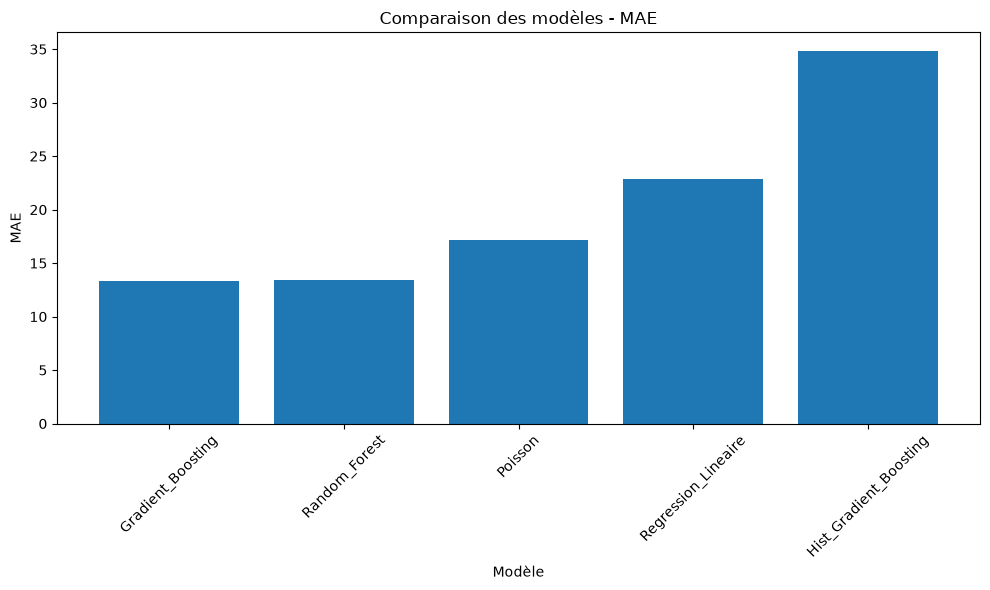

In [36]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparaison["Modele"],
    comparaison["MAE"]
)

plt.title(
    "Comparaison des modèles - MAE"
)

plt.xlabel("Modèle")
plt.ylabel("MAE")

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

25- Sélection du meilleur modèle

Pour une variable représentant un nombre d'infections, je recommande de retenir prioritairement le modèle ayant le MAE le plus faible, car :

MAE = erreur absolue moyenne en nombre d'infections.

In [37]:
meilleur_nom = (
    comparaison
    .sort_values("MAE")
    .iloc[0]["Modele"]
)

meilleur_modele = (
    modeles_entraines[
        meilleur_nom
    ]
)

print(
    "✓ Meilleur modèle :",
    meilleur_nom
)

✓ Meilleur modèle : Gradient_Boosting


26- Comparaison réel/prédit

In [38]:
predictions_meilleur = (
    meilleur_modele.predict(
        X_test
    )
)
predictions_meilleur = np.maximum(
    predictions_meilleur,
    0
)
resultats_validation = test[
    [COL_ANNEE, COL_PROVINCE, TARGET]
].copy()

resultats_validation[
    "Prediction"
] = np.round(
    predictions_meilleur,
    1
)

display(
    resultats_validation
)

,Année,Province,infections,Prediction
28,2025,CB,6,25.4
29,2025,LOC,1,7.7
30,2025,LOGONE ORIENTAL,2,3.3
31,2025,MC,26,61.3
32,2025,MKE,83,61.3
33,2025,NDJ,4,14.2
34,2025,SLM,6,14.3
35,2025,Tandjile,18,21.4


26- Graphique réel/prédit

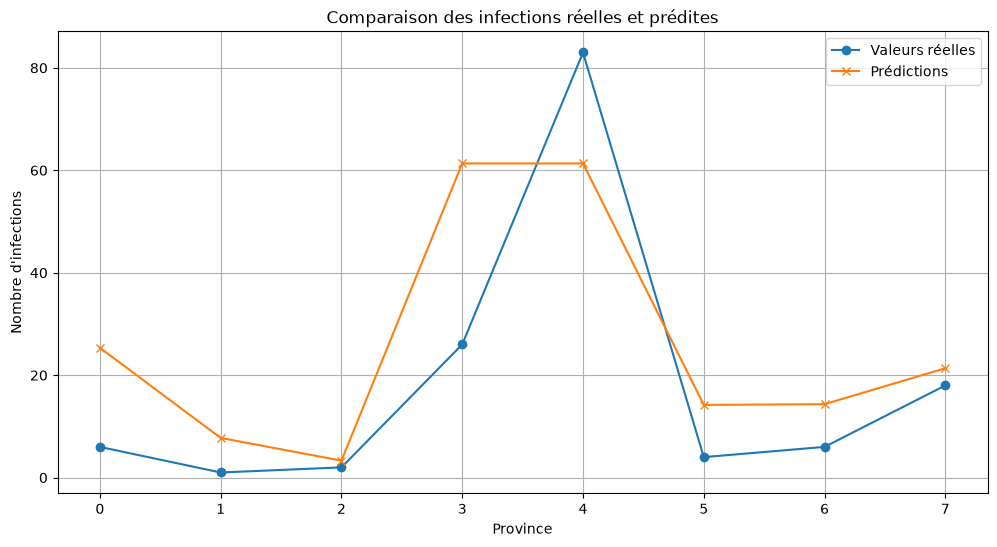

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(
    range(len(y_test)),
    y_test.values,
    marker="o",
    label="Valeurs réelles"
)
plt.plot(
    range(len(predictions_meilleur)),
    predictions_meilleur,
    marker="x",
    label="Prédictions"
)
plt.title(
    "Comparaison des infections réelles et prédites"
)
plt.xlabel(
    "Province"
)
plt.ylabel(
    "Nombre d'infections"
)
plt.legend()
plt.grid(True)
plt.show()

27- Entraînement final

In [40]:
meilleur_modele.fit(
    data_ml[FEATURES],
    data_ml[TARGET]
)
print(
    "✓ Meilleur modèle réentraîné sur toutes les données 2022-2025."
)

✓ Meilleur modèle réentraîné sur toutes les données 2022-2025.


28-Préparation de la prédiction 2026

In [41]:
# Les indicateurs 2025 deviennent les variables explicatives
# pour prevoir les infections de 2026.

toutes_provinces = sorted(df[COL_PROVINCE].dropna().unique())

donnees_2025 = data_model[
    data_model[COL_ANNEE] == 2025
].copy()

donnees_2026 = (
    donnees_2025
    .set_index(COL_PROVINCE)
    .reindex(toutes_provinces)
    [["infections", "non_attaches", "non_isolees", "eau_contaminee"]]
    .fillna(0)
    .reset_index()
    .rename(columns={"index": COL_PROVINCE})
)

donnees_2026 = donnees_2026.rename(
    columns={
        "infections": "infections_precedentes",
        "non_attaches": "non_attaches_precedents",
        "non_isolees": "non_isolees_precedentes",
        "eau_contaminee": "eau_contaminee_precedente"
    }
)

print(
    f"Provinces incluses dans la prevision 2026 : {len(donnees_2026)} / {len(toutes_provinces)}"
)
display(donnees_2026)

Provinces incluses dans la prevision 2026 : 10 / 10


,Province,infections_precedentes,non_attaches_precedents,non_isolees_precedentes,eau_contaminee_precedente
0,CB,6.0,5.0,3.0,3.0
1,Guera,0.0,0.0,0.0,0.0
2,LOC,1.0,1.0,1.0,0.0
3,LOGONE ORIENTAL,2.0,2.0,0.0,0.0
4,MC,26.0,18.0,10.0,8.0
5,MDL,0.0,0.0,0.0,0.0
6,MKE,83.0,63.0,25.0,20.0
7,NDJ,4.0,3.0,1.0,1.0
8,SLM,6.0,5.0,4.0,1.0
9,Tandjile,18.0,12.0,12.0,9.0


29- Prédiction 2026

In [42]:
predictions_2026 = (
    meilleur_modele.predict(
        donnees_2026[FEATURES]
    )
)
predictions_2026 = np.maximum(
    predictions_2026,
    0
)
resultat_2026 = pd.DataFrame({
    "Province":
        donnees_2026[COL_PROVINCE],
    "Infections_prevues_2026":
        np.round(
            predictions_2026,
            0
        ).astype(int)
})

resultat_2026 = (
    resultat_2026
    .sort_values(
        "Infections_prevues_2026",
        ascending=False
    )
)

display(resultat_2026)

,Province,Infections_prevues_2026
6,MKE,26
4,MC,18
9,Tandjile,18
8,SLM,14
3,LOGONE ORIENTAL,6
0,CB,6
7,NDJ,4
1,Guera,3
5,MDL,3
2,LOC,2


30- Total infection prédite sur le plan national

In [44]:
total_2026 = (
    resultat_2026[
        "Infections_prevues_2026"
    ].sum()
)

print(
    f"Nombre total d'infections animales "
    f"prévues pour 2026 : {total_2026}"
)

Nombre total d'infections animales prévues pour 2026 : 100


31- Classement des provinces

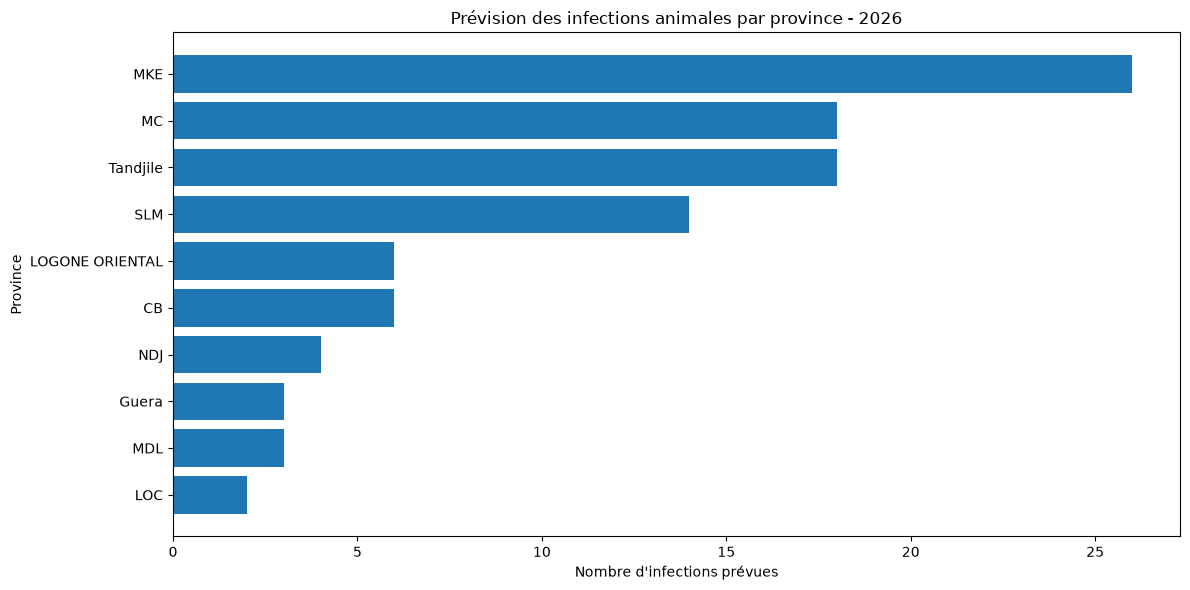

In [45]:
plt.figure(figsize=(12, 6))

plt.barh(
    resultat_2026["Province"],
    resultat_2026[
        "Infections_prevues_2026"
    ]
)
plt.gca().invert_yaxis()
plt.title(
    "Prévision des infections animales par province - 2026"
)
plt.xlabel(
    "Nombre d'infections prévues"
)
plt.ylabel(
    "Province"
)
plt.tight_layout()

plt.show()

32 -Catégorisation du niveau de risque

In [46]:
q33 = resultat_2026[
    "Infections_prevues_2026"
].quantile(0.33)

q66 = resultat_2026[
    "Infections_prevues_2026"
].quantile(0.66)


def niveau_risque(valeur):

    if valeur <= q33:
        return "Faible"

    elif valeur <= q66:
        return "Moyen"

    else:
        return "Élevé"


resultat_2026["Niveau_risque"] = (
    resultat_2026[
        "Infections_prevues_2026"
    ]
    .apply(niveau_risque)
)

display(resultat_2026)

,Province,Infections_prevues_2026,Niveau_risque
6,MKE,26,Élevé
4,MC,18,Élevé
9,Tandjile,18,Élevé
8,SLM,14,Élevé
3,LOGONE ORIENTAL,6,Moyen
0,CB,6,Moyen
7,NDJ,4,Moyen
1,Guera,3,Faible
5,MDL,3,Faible
2,LOC,2,Faible


33- Sauvegarde du modèle

In [47]:
import joblib

MODEL_DIR = Path("models")

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = (
    MODEL_DIR /
    "meilleur_modele_infections_animales.pkl"
)

bundle = {

    "model": meilleur_modele,

    "features": FEATURES,

    "target": TARGET,

    "annees": [
        2022,
        2023,
        2024,
        2025
    ],

    "type_modele":
        meilleur_nom
}

joblib.dump(
    bundle,
    MODEL_PATH
)

print(
    "✓ Modèle sauvegardé :"
)

print(
    MODEL_PATH.resolve()
)

✓ Modèle sauvegardé :
C:\Users\dell\Desktop\projet_final\projet_final\models\meilleur_modele_infections_animales.pkl


34- Sauvegarde des prédictions

In [48]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = DATA_DIR / "predictions_2026.csv"

resultat_export = resultat_2026.rename(
    columns={"Infections_prevues_2026": "Infections_prevues"}
)

resultat_export.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "\u2713 Resultats sauvegardes :",
    OUTPUT_PATH.resolve()
)

✓ Resultats sauvegardes : C:\Users\dell\Desktop\projet_final\projet_final\data\predictions_2026.csv


## Extension — Districts et villages à risque pour 2026

Les sections précédentes prévoient un **volume** de infections par province. Cette
section complète le dispositif avec un **classement de risque par district et
par village pour 2026**, en réutilisant la méthodologie déjà validée sur ce
projet : panel zone × mois, variable de transmission différée (10-14 mois),
classification par Gradient Boosting, validation temporelle stricte
(entraînement ≤ 2024, test 2025 jamais vu), puis projection récursive mois
par mois pour 2026.

Les résultats sont exportés vers `data/districts_risque_2026.csv` et
`data/villages_risque_2026.csv`, consommés par `app.py`.

In [49]:
import unicodedata, re
import numpy as np, pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

def normaliser_texte(v):
    if pd.isna(v): return np.nan
    v = str(v).strip()
    v = unicodedata.normalize("NFKD", v).encode("ascii", "ignore").decode()
    return re.sub(r"[\s_]+", " ", v).strip().upper()

def parser_date(v):
    if pd.isna(v): return pd.NaT
    v = str(v).strip()
    for fmt in ("%d/%m/%Y", "%Y-%m-%d", "%d-%m-%Y"):
        try: return pd.to_datetime(v, format=fmt)
        except ValueError: continue
    return pd.NaT

FENETRE_INCUBATION = (10, 14)
MOIS_2026 = pd.period_range("2026-01", "2026-12", freq="M")
FEATURES = ["lag1","lag2","lag3","lag12","roll3","roll12","cum","sin","cos","t","lat","lon","risque_10_14"]

df = pd.read_csv("Infections_Animales.csv", sep=";", encoding="utf-8-sig")
df["date_emergence"] = df["Date d'emergence"].apply(parser_date)
df["date_detection"] = df["Date de detection"].apply(parser_date)
df["lat"] = pd.to_numeric(df["Latitude"].astype(str).str.replace(",", "."), errors="coerce")
df["lon"] = pd.to_numeric(df["Longitude"].astype(str).str.replace(",", "."), errors="coerce")
df["province_n"] = df["Province"].apply(normaliser_texte)
df["district_n"] = df["District"].apply(normaliser_texte)
df["village_n"] = (df["Village"].apply(normaliser_texte) + " | " + df["Zone"].apply(normaliser_texte) + " | " + df["District"].apply(normaliser_texte))
df["isolee_n"] = df["Infection Isolee?"].apply(normaliser_texte)
df["contam_n"] = df["Contamination des Sources d'eau"].apply(normaliser_texte)
df["attache_n"] = df["Animal Attache"].apply(normaliser_texte)
df = df.dropna(subset=["date_emergence"]).copy()
df["ym"] = df["date_emergence"].dt.to_period("M")
df["risque_transmission"] = ((df["isolee_n"]=="NON") & ((df["contam_n"]=="OUI")|(df["attache_n"]=="NON"))).astype(int)

# ---- Les 4 facteurs de risque connus (au niveau de chaque infection) ----
# Detection tardive : la detection n'a pas devance l'emergence du ver
# (surveillance non proactive sur cet animal) -> ~15% des cas, taux
# plausible pour un facteur de risque.
df["facteur_detection_tardive"] = (df["date_detection"] >= df["date_emergence"]).astype(int)
df["facteur_non_attache"] = (df["attache_n"] == "NON").astype(int)
df["facteur_eau_contaminee"] = (df["contam_n"] == "OUI").astype(int)
df["facteur_non_isolee"] = (df["isolee_n"] == "NON").astype(int)
FACTEURS = ["facteur_detection_tardive", "facteur_non_attache", "facteur_eau_contaminee", "facteur_non_isolee"]
NOMS_FACTEURS = {
    "facteur_detection_tardive": "Détection tardive",
    "facteur_non_attache": "Animal non attaché",
    "facteur_eau_contaminee": "Source d'eau contaminée",
    "facteur_non_isolee": "Infection non isolée",
}

mois_hist = pd.period_range(df["ym"].min(), "2025-12", freq="M")

def construire_panel(df, col_zone, mois_hist):
    zones = sorted(df[col_zone].dropna().unique())
    # IMPORTANT : on mappe vers la casse BRUTE de la colonne "Province" du
    # CSV source (pas "province_n" normalisee), pour que les valeurs
    # correspondent exactement a celles utilisees dans predictions_2026.csv
    # et dans le filtre de la sidebar de app.py (ex. "Tandjile", pas "TANDJILE").
    mapping_province = df.dropna(subset=[col_zone]).groupby(col_zone)["Province"].agg(lambda s: s.value_counts().idxmax())
    idx = pd.MultiIndex.from_product([zones, mois_hist], names=["zone","ym"])
    panel = pd.DataFrame(index=idx).reset_index()
    cas = df.groupby([col_zone,"ym"]).size().rename("cas")
    risq = df.groupby([col_zone,"ym"])["risque_transmission"].sum().rename("risque")
    panel = panel.merge(cas, left_on=["zone","ym"], right_index=True, how="left").fillna({"cas":0})
    panel = panel.merge(risq, left_on=["zone","ym"], right_index=True, how="left").fillna({"risque":0})
    panel["y"] = (panel.cas>0).astype(int)
    panel["province"] = panel["zone"].map(mapping_province)
    coords = df.dropna(subset=["lat","lon"]).groupby(col_zone)[["lat","lon"]].median()
    panel = panel.merge(coords, left_on="zone", right_index=True, how="left")
    g = panel.groupby("zone")
    for L in [1,2,3,12]:
        panel[f"lag{L}"] = g["cas"].shift(L)
    panel["roll3"] = g["cas"].shift(1).transform(lambda s: s.rolling(3,min_periods=1).sum())
    panel["roll12"] = g["cas"].shift(1).transform(lambda s: s.rolling(12,min_periods=1).sum())
    panel["cum"] = g["cas"].cumsum() - panel["cas"]
    panel["risque_10_14"] = g["risque"].transform(lambda s: s.shift(FENETRE_INCUBATION[0]).rolling(FENETRE_INCUBATION[1]-FENETRE_INCUBATION[0]+1, min_periods=1).sum())
    panel["mois"] = panel.ym.dt.month
    panel["sin"] = np.sin(2*np.pi*panel.mois/12); panel["cos"] = np.cos(2*np.pi*panel.mois/12)
    annee_min = panel.ym.dt.year.min()
    panel["t"] = (panel.ym.dt.year - annee_min)*12 + panel.mois
    return panel.sort_values(["zone","ym"]).reset_index(drop=True), annee_min

def entrainer_et_valider(panel):
    train = panel[panel.ym.dt.year <= 2024]
    test = panel[panel.ym.dt.year == 2025]
    metriques = None
    if len(test) and test["y"].sum() > 0:
        m = HistGradientBoostingClassifier(max_iter=250, learning_rate=.07, max_leaf_nodes=12, l2_regularization=1., random_state=0).fit(train[FEATURES], train.y)
        proba = m.predict_proba(test[FEATURES])[:,1]
        metriques = {"AUC": roc_auc_score(test.y, proba), "PR_AUC": average_precision_score(test.y, proba)}
    m_final = HistGradientBoostingClassifier(max_iter=250, learning_rate=.07, max_leaf_nodes=12, l2_regularization=1., random_state=0).fit(panel[FEATURES], panel.y)
    return m_final, metriques

def prevoir_2026(panel, modele, annee_min):
    coords = panel[["zone","lat","lon","province"]].drop_duplicates("zone").set_index("zone")
    cas_series = panel.pivot_table(index="ym", columns="zone", values="cas", aggfunc="sum").fillna(0)
    risque_series = panel.pivot_table(index="ym", columns="zone", values="risque", aggfunc="sum").fillna(0)
    resultats = []
    for mois_cible in MOIS_2026:
        hist = cas_series[cas_series.index < mois_cible]
        lag1 = hist.iloc[-1] if len(hist)>=1 else pd.Series(0,index=cas_series.columns)
        lag2 = hist.iloc[-2] if len(hist)>=2 else pd.Series(0,index=cas_series.columns)
        lag3 = hist.iloc[-3] if len(hist)>=3 else pd.Series(0,index=cas_series.columns)
        lag12 = hist.iloc[-12] if len(hist)>=12 else pd.Series(0,index=cas_series.columns)
        roll3 = hist.iloc[-3:].sum() if len(hist)>=1 else pd.Series(0,index=cas_series.columns)
        roll12 = hist.iloc[-12:].sum() if len(hist)>=1 else pd.Series(0,index=cas_series.columns)
        cum = hist.sum()
        fen = risque_series[(risque_series.index>=mois_cible-FENETRE_INCUBATION[1]) & (risque_series.index<=mois_cible-FENETRE_INCUBATION[0])]
        risque_10_14 = fen.sum() if len(fen) else pd.Series(0,index=cas_series.columns)
        feat = pd.DataFrame({"zone": cas_series.columns})
        feat["lag1"]=feat.zone.map(lag1); feat["lag2"]=feat.zone.map(lag2); feat["lag3"]=feat.zone.map(lag3); feat["lag12"]=feat.zone.map(lag12)
        feat["roll3"]=feat.zone.map(roll3); feat["roll12"]=feat.zone.map(roll12); feat["cum"]=feat.zone.map(cum); feat["risque_10_14"]=feat.zone.map(risque_10_14)
        feat["lat"]=feat.zone.map(coords["lat"]); feat["lon"]=feat.zone.map(coords["lon"])
        feat["mois"]=mois_cible.month
        feat["sin"]=np.sin(2*np.pi*feat.mois/12); feat["cos"]=np.cos(2*np.pi*feat.mois/12)
        feat["t"]=(mois_cible.year-annee_min)*12+mois_cible.month
        feat=feat.dropna(subset=["lat","lon"])
        proba = modele.predict_proba(feat[FEATURES])[:,1]
        feat["proba"]=proba; feat["ym"]=mois_cible; feat["province"]=feat.zone.map(coords["province"])
        resultats.append(feat[["ym","zone","province","proba"]])
        pseudo = pd.Series(0.0, index=cas_series.columns); pseudo.update(feat.set_index("zone")["proba"])
        cas_series.loc[mois_cible]=pseudo; risque_series.loc[mois_cible]=0.0
    return pd.concat(resultats, ignore_index=True)

for col_zone, label, fichier in [("district_n","District","data/districts_risque_2026.csv"), ("village_n","Village","data/villages_risque_2026.csv")]:
    panel, annee_min = construire_panel(df, col_zone, mois_hist)
    modele, metriques = entrainer_et_valider(panel)
    print(f"{label}: panel {panel.shape}, metriques {metriques}")
    prev = prevoir_2026(panel, modele, annee_min)
    resume = prev.groupby("zone")["proba"].agg(risque_moyen_2026="mean", risque_max_2026="max")
    pic = prev.loc[prev.groupby("zone")["proba"].idxmax(), ["zone","ym"]].set_index("zone")["ym"].astype(str).rename("mois_pic_2026")
    province_map = prev.drop_duplicates("zone").set_index("zone")["province"]

    # Taux historiques des 4 facteurs de risque connus, calcules sur
    # l'ensemble des infections passees de la zone (2022-2025) -- ce sont
    # des statistiques descriptives de l'historique, pas des predictions.
    facteurs_zone = df.groupby(col_zone)[FACTEURS].mean().rename(columns=NOMS_FACTEURS)

    resume = (
        resume.join(pic).join(province_map).join(facteurs_zone)
        .reset_index().rename(columns={"zone": label, "province": "Province"})
    )
    resume = resume.sort_values("risque_moyen_2026", ascending=False)
    resume.to_csv(fichier, index=False, encoding="utf-8-sig")
    print(f"-> {fichier} exporte, {len(resume)} lignes")
    print(resume.head(8))
    print()


District: panel (1776, 20), metriques {'AUC': 0.798185164576467, 'PR_AUC': 0.4799639585350252}
-> data/districts_risque_2026.csv exporte, 36 lignes
      District  risque_moyen_2026  risque_max_2026 mois_pic_2026  Province  \
12      BONGOR           0.348955         0.901038       2026-05       MKE   
19  GUELENDENG           0.219998         0.545138       2026-09       MKE   
35        SARH           0.218506         0.424350       2026-07        MC   
27         LAI           0.206511         0.614706       2026-07  Tandjile   
14   DANAMADJI           0.177656         0.392998       2026-08        MC   
25       KOYOM           0.155754         0.418400       2026-08       MKE   
21      HARAZE           0.142205         0.438341       2026-09       SLM   
9         BERE           0.123754         0.564459       2026-08  Tandjile   

    Détection tardive  Animal non attaché  Source d'eau contaminée  \
12           0.160920            0.609195                 0.183908   
19       

Conclusion du projet
# Conclusion

L'analyse exploratoire a permis de caractériser les infections animales
de la dracunculose au Tchad sur la période 2022-2025.

Les données ont été nettoyées, les doublons et les valeurs manquantes
ont été contrôlés et les principaux facteurs de risque ont été
transformés en indicateurs numériques.

Pour la modélisation, plusieurs algorithmes de Machine Learning ont
été comparés :

- Régression linéaire ;
- Random Forest ;
- Gradient Boosting ;
- HistGradientBoosting ;
- Régression de Poisson.

La validation a été réalisée dans le respect de l'ordre chronologique
des données. Les données antérieures à 2025 ont été utilisées pour
l'entraînement et l'année 2025 pour la validation.

Le meilleur modèle a été sélectionné sur la base de l'erreur absolue
moyenne (MAE).

Après sélection, le modèle a été réentraîné sur l'ensemble des données
disponibles jusqu'en 2025 afin de produire une estimation du nombre
d'infections animales par province pour 2026.

Les résultats constituent une aide à la surveillance et à la décision.
Ils ne doivent pas être interprétés comme une prédiction certaine du
nombre réel de cas.